**Correlation analysis**

1. Загружаем и просматриваем данные

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as ss

df = pd.read_csv('lesson_002_data.csv')
df.describe()

Много пропущенных данных для model_onboarding_score_1 (скоринг onboarding ML-модели), Scores(кол-во бонусных баллов), Revenue (кол-во потраченных пользователем денег). Не совсем понятно, с чем это связано. В дальнейшем эти показатели - не самые лучшие кандидаты на прокси-метрики: снижается достоверность корреляции из-за снижения количества наблюдений, также не можем потом в тесте прогнозировать количество наблюдений.

In [4]:
missing = pd.DataFrame({
    'count': df.isna().sum()
})

print(missing)

                          count
Unnamed: 0                    0
CustomerId                    0
Surname                       0
model_onboarding_score_1   2138
Geography                     0
Gender                        0
Age                           0
Periods                       0
Scores                     1300
NumOfProducts                 0
HasCard                       0
IsActiveMember                0
Revenue                    9000
Subscribe                     0


2. Обычная корреляционная матрица (Пирсона) по всем числовым метрикам:

In [5]:
df_numeric = df.select_dtypes(include='number')
corr_matrix = df_numeric.corr()

print(corr_matrix)

                          Unnamed: 0  CustomerId  model_onboarding_score_1  \
Unnamed: 0                  1.000000    0.004202                 -0.012606   
CustomerId                  0.004202    1.000000                  0.011655   
model_onboarding_score_1   -0.012606    0.011655                  1.000000   
Age                         0.000783    0.009497                  0.180248   
Periods                    -0.006495   -0.014883                 -0.011951   
Scores                     -0.008788   -0.008512                  0.070690   
NumOfProducts              -0.015102    0.000404                  0.462997   
HasCard                     0.000724    0.005151                  0.386394   
IsActiveMember             -0.012044   -0.001665                  0.110073   
Revenue                    -0.023293    0.020915                 -0.024589   
Subscribe                  -0.016571   -0.006248                  0.632287   

                               Age   Periods    Scores  NumOfPr

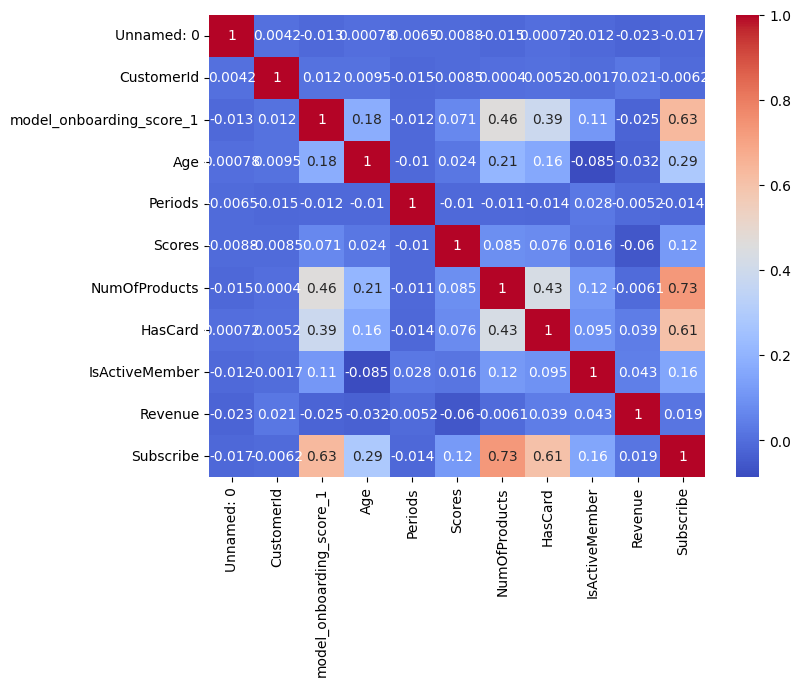

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Самую высокую корреляцию показывает метрика NumOfProducts, поменьше - model_onboarding_score_1 и HasCard.
Но корреляция Пирсона по сути измеряет линейную зависимость (рассчитывает числовые расстояния между показателями), предназначен для непрерывных переменных, а потому чувствителен к кодировке категориальных значений.

Для выявления корреляции между категориальными значениями можно использовать Cramer's V метод, а для корреляции между категориальными и непрерывными переменными - point biserial correlation (для бинарных категориальных переменных, т.к. целевая метрика - Subscribe (факт продления подписки) - категориальная бинарная).

Непрерывные метрики:
*   model_onboarding
*   age
* Periods
* Scores
* NumOfProducts
* Revenue

Категориальные метрики:
* HasCard
* IsActiveMember
* Geography
* Gender



3. Cramer's V correlation между категориальными значениями

In [7]:
def cramers_v(confusion_matrix):
    """ calculate Cramers V statistic for categorial-categorial association.
        uses correction from Bergsma and Wicher,
        Journal of the Korean Statistical Society 42 (2013): 323-328
    """
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


3.1. Корреляция между Subscribe и Geography

In [8]:
confusion_matrix = pd.crosstab(df['Subscribe'], df['Geography'])
cramers_v(confusion_matrix.values)

np.float64(0.17299857464855706)

3.2. Корреляция между Subscribe и Gender

In [9]:
confusion_matrix = pd.crosstab(df['Subscribe'], df['Gender'])
cramers_v(confusion_matrix.values)

np.float64(0.10579681691659651)

3.3. Корреляция между Subscribe и HasCard

In [10]:
confusion_matrix = pd.crosstab(df['Subscribe'], df['HasCard'])
cramers_v(confusion_matrix.values)

np.float64(0.6051258060022203)

3.4. Корреляция между Subscribe и IsActiveMember

In [11]:
confusion_matrix = pd.crosstab(df['Subscribe'], df['IsActiveMember'])
cramers_v(confusion_matrix.values)

np.float64(0.15556652756866268)

Наибольшая корреляция (положительная) с категориальными переменными у метрики HasCard - привязана кредитная карта. Если пользователь в какой-то момент привязал кредитную карту, то:
* хотел совершить покупку, т.е. уже в целевой аудитории продукта, сервис ему интересен / нужен
* снижены транзакционные издержки на совершение следующей покупки (продление подписки) - не надо привязывать карту, ходить по страницам авторизаций и т.д. При это транзакционные издержки на "отвязать" карту (остановить подписку) присутствуют, возможно, лень этим заняться, переносят решение на следующий месяц.

Интересно, что корреляция с IsActiveMember небольшая. Возможно, категория VIP-жилья указывает на то, что людям часто действительно лень отвязать карту / забыл про автоматическое продление, и продолжается оплата без фактического пользования продуктом.
(это предположение, потому что не совсем понятно, что это такое - VIP жилье по подписке: ты правда где-то живешь или подписка означает наличие вариантов, если захочешь что-то снять??)

4. Point biserial correlation между категориальной метрикой Subscribe и непрерывными метриками

In [12]:
import scipy.stats as stats
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
df['Subscribe'] = le.fit_transform(df['Subscribe'])

4.1. Point biserial correlation между Subscribe и Age

In [15]:
stats.pointbiserialr(df['Subscribe'], df['Age'])

SignificanceResult(statistic=np.float64(0.28532303783506824), pvalue=np.float64(1.2399313093420416e-186))

4.2. Point biserial correlation между Subscribe и Periods

In [16]:
stats.pointbiserialr(df['Subscribe'], df['Periods'])

SignificanceResult(statistic=np.float64(-0.014000612253444665), pvalue=np.float64(0.16152684949473145))

4.3. Point biserial correlation между Subscribe и NumOfProducts

In [18]:
stats.pointbiserialr(df['Subscribe'], df['NumOfProducts'])

SignificanceResult(statistic=np.float64(0.7292873613718003), pvalue=np.float64(0.0))

Есть небольшая значимая положительная корреляция с возрастом клиента.
Интересно, что нет корреляции между сроком подписки и ее продолжением.

Наибольшая значимая положительная корреляция наблюдается с показателем количества дополнительных услуг. Чем больше человек вовлечен во всю систему продуктов, тем большее ценности они ему приносят, тем вероятнее он продлит подписку.
Это наиболее вероятный кандидат на прокси-метрику.
